In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

Column names: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dtypes:
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


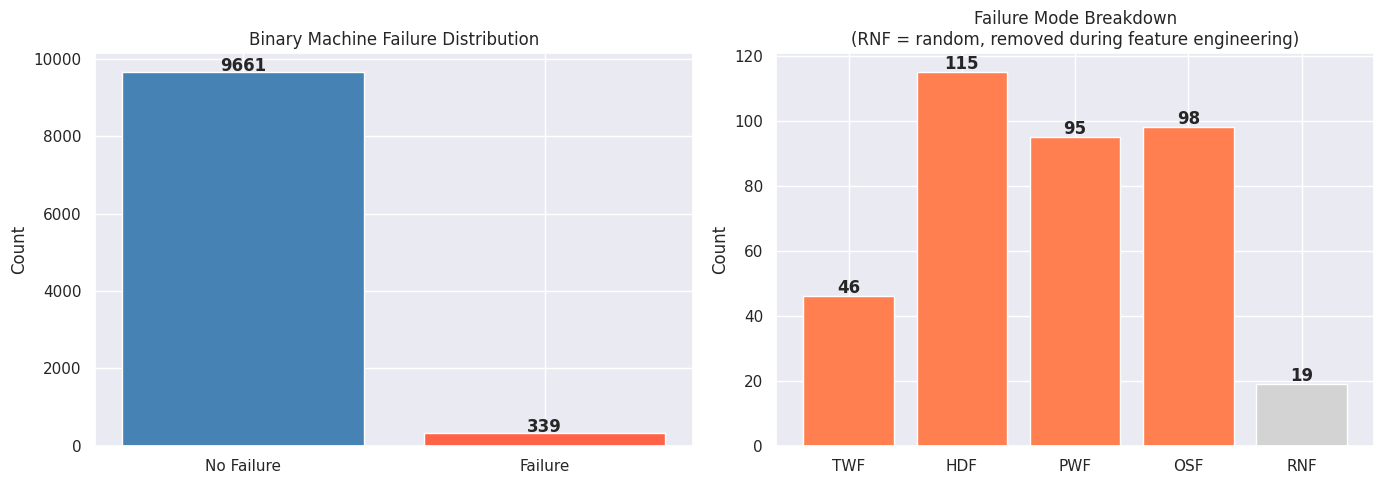

Imbalance ratio: 1 failure per 28 non-failures
RNF rows (19) are dropped by engineer_features() — no learnable signal


In [3]:
# Class imbalance and failure modes
failure_counts = df['Machine failure'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['No Failure', 'Failure'], failure_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Binary Machine Failure Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_counts = [df[m].sum() for m in failure_modes]
colors = ['coral'] * 4 + ['lightgray']  # RNF greyed out — removed in pipeline
axes[1].bar(failure_modes, mode_counts, color=colors)
axes[1].set_title('Failure Mode Breakdown\n(RNF = random, removed during feature engineering)')
axes[1].set_ylabel('Count')
for i, v in enumerate(mode_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/class_imbalance.png', dpi=150)
plt.show()

print(f"Imbalance ratio: 1 failure per {int(failure_counts.iloc[0]/failure_counts.iloc[1])} non-failures")
print(f"RNF rows ({df['RNF'].sum()}) are dropped by engineer_features() — no learnable signal")


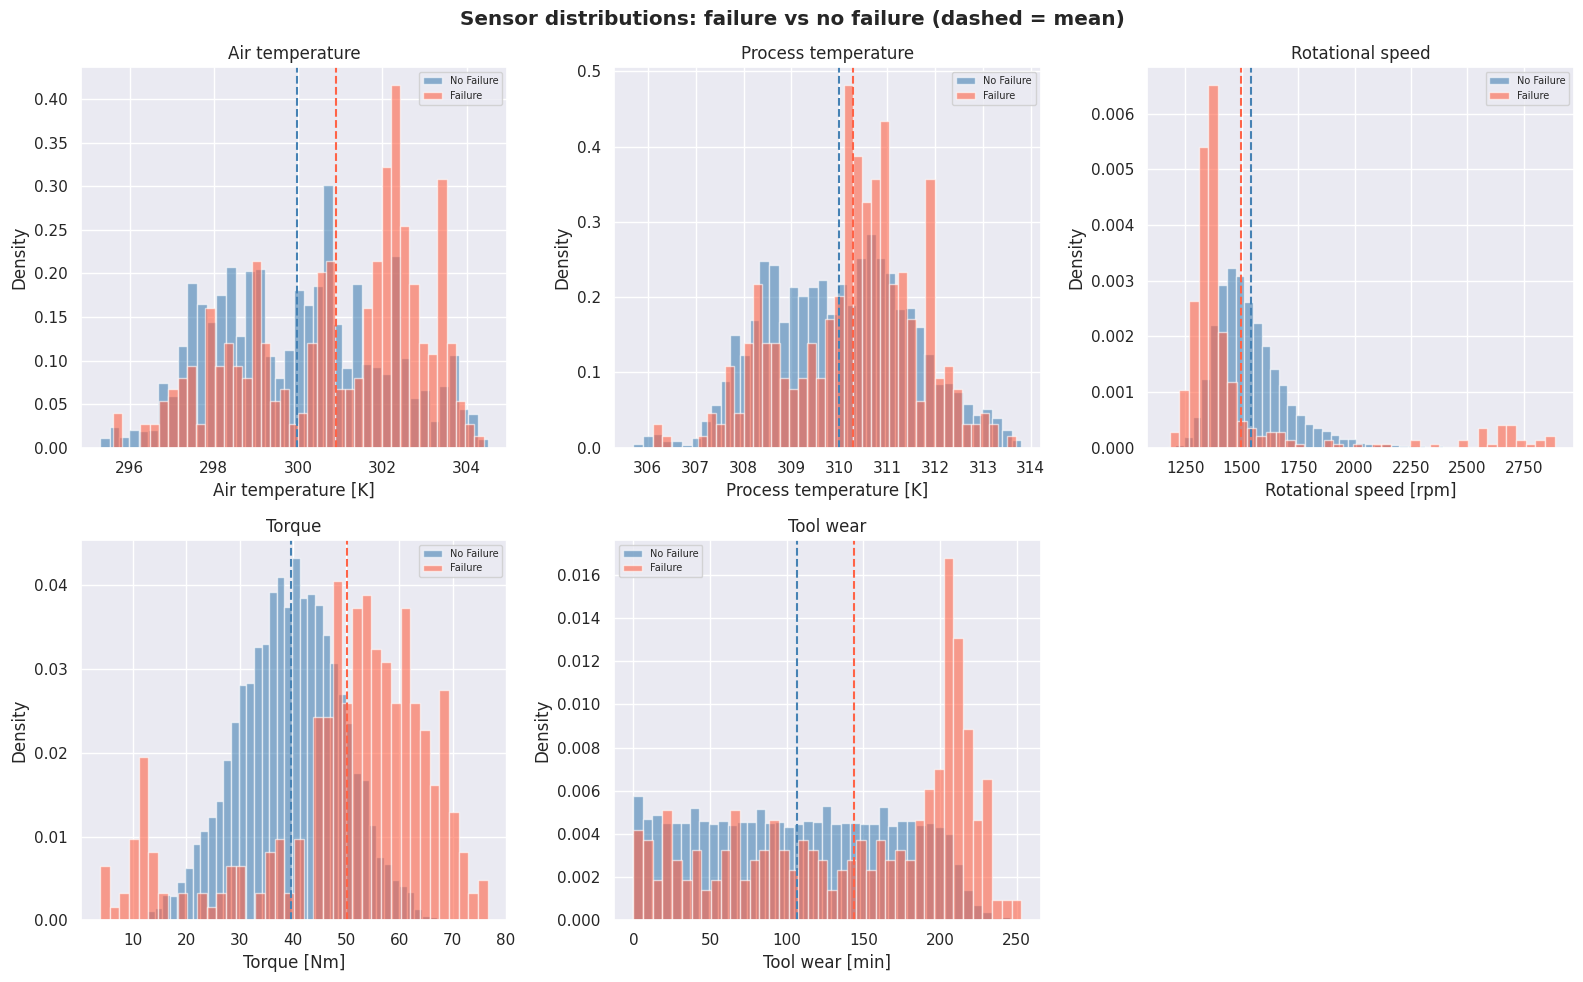

In [4]:
# Q: At what sensor values do failures actually occur?
sensor_features = ['Air temperature [K]', 'Process temperature [K]',
                   'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

no_fail = df[df['Machine failure'] == 0]
fail    = df[df['Machine failure'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for i, col in enumerate(sensor_features):
    ax = axes_flat[i]
    ax.hist(no_fail[col], bins=40, alpha=0.6, label='No Failure', color='steelblue', density=True)
    ax.hist(fail[col],    bins=40, alpha=0.6, label='Failure',    color='tomato',    density=True)
    ax.axvline(no_fail[col].mean(), color='steelblue', ls='--', lw=1.5)
    ax.axvline(fail[col].mean(),    color='tomato',    ls='--', lw=1.5)
    ax.set_title(col.split('[')[0].strip())
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

axes_flat[-1].axis('off')
plt.suptitle('Sensor distributions: failure vs no failure (dashed = mean)', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feature_distributions.png', dpi=150)
plt.show()


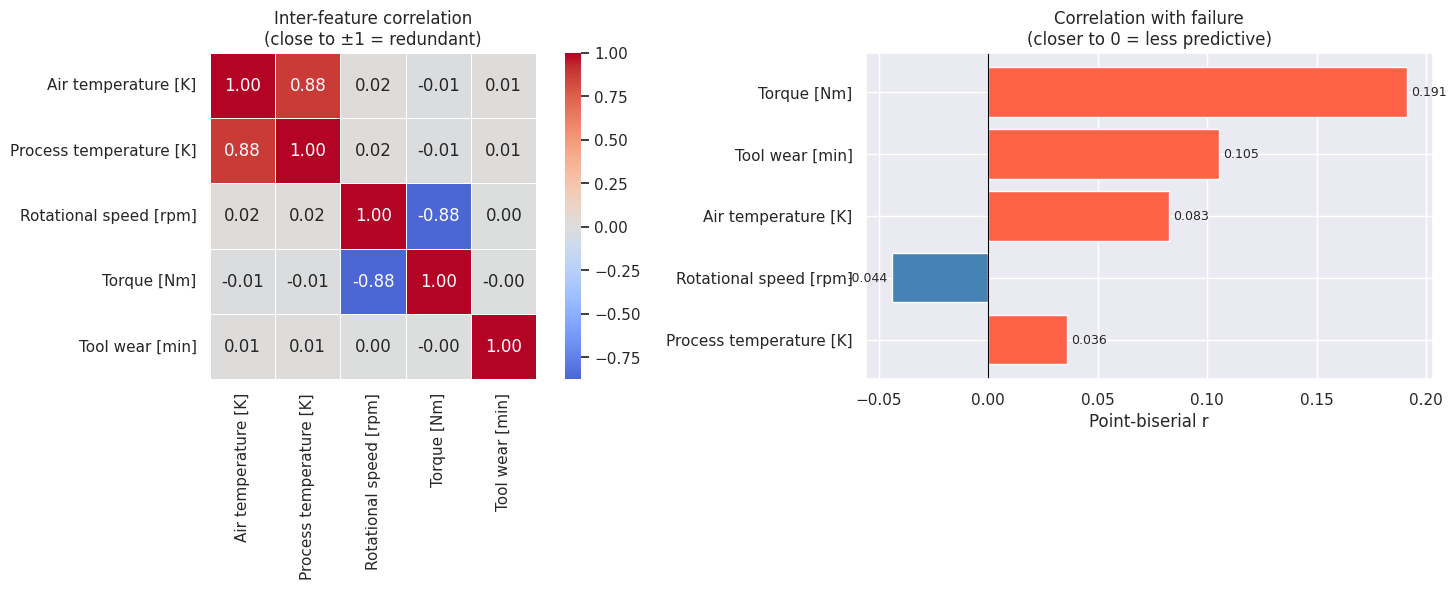

In [5]:
# Q: Which features are correlated with each other, and which predict failure?
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature-to-feature correlation
feature_corr = df[sensor_features].corr()
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Inter-feature correlation\n(close to ±1 = redundant)')

# Feature-target correlation
correlations = {col: stats.pointbiserialr(df['Machine failure'], df[col])[0]
                for col in sensor_features}
corr_s = pd.Series(correlations).sort_values(key=abs, ascending=True)
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_s.values]
axes[1].barh(corr_s.index, corr_s.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Correlation with failure\n(closer to 0 = less predictive)')
axes[1].set_xlabel('Point-biserial r')
for i, (val, name) in enumerate(zip(corr_s.values, corr_s.index)):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i, f'{val:.3f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/correlations.png', dpi=150)
plt.show()


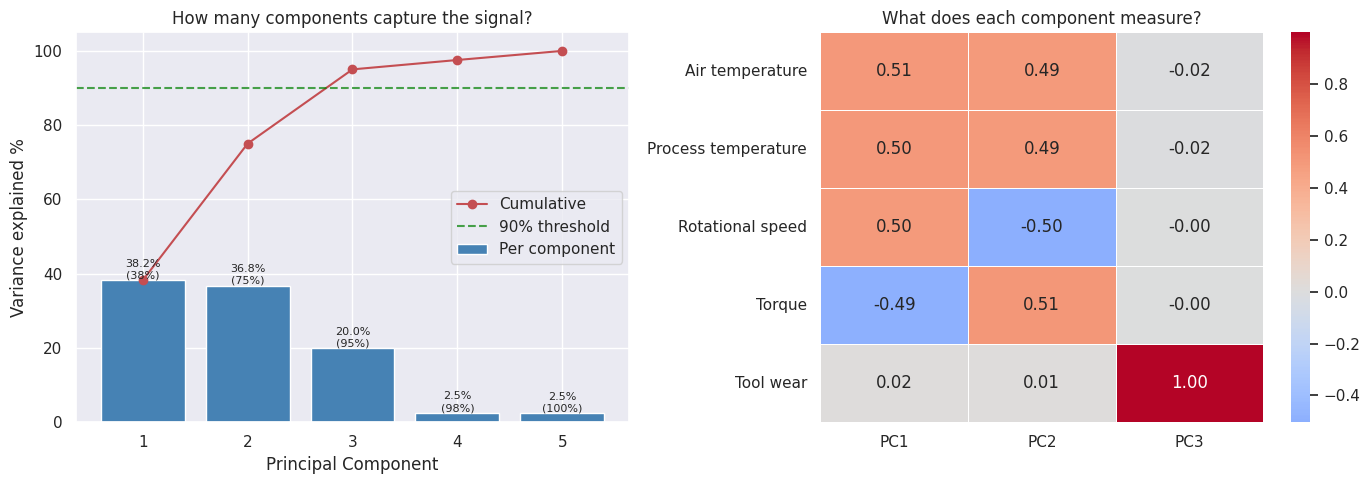

3 components capture 90% of variance — confirms some raw features are redundant.
Note: PCA is useful for EDA here, but the model is XGBoost (tree-based)
which handles correlated features natively. We keep all raw features.


In [6]:
# Q: Can we reduce 5 features down without losing information?
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[sensor_features])

pca = PCA()
pca.fit(X_scaled)

explained  = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), explained, color='steelblue', label='Per component')
axes[0].plot(range(1, 6), cumulative, 'ro-', label='Cumulative')
axes[0].axhline(90, color='green', ls='--', alpha=0.7, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained %')
axes[0].set_title('How many components capture the signal?')
axes[0].set_xticks(range(1, 6))
axes[0].legend()
for i, (v, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, v+0.5, f'{v:.1f}%\n({c:.0f}%)', ha='center', fontsize=8)

loadings = pd.DataFrame(pca.components_[:3].T,
                         index=[f.split('[')[0].strip() for f in sensor_features],
                         columns=['PC1', 'PC2', 'PC3'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('What does each component measure?')

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/pca.png', dpi=150)
plt.show()

n_for_90 = int(np.argmax(cumulative >= 90) + 1)
print(f'{n_for_90} components capture 90% of variance — confirms some raw features are redundant.')
print(f'Note: PCA is useful for EDA here, but the model is XGBoost (tree-based)')
print(f'which handles correlated features natively. We keep all raw features.')


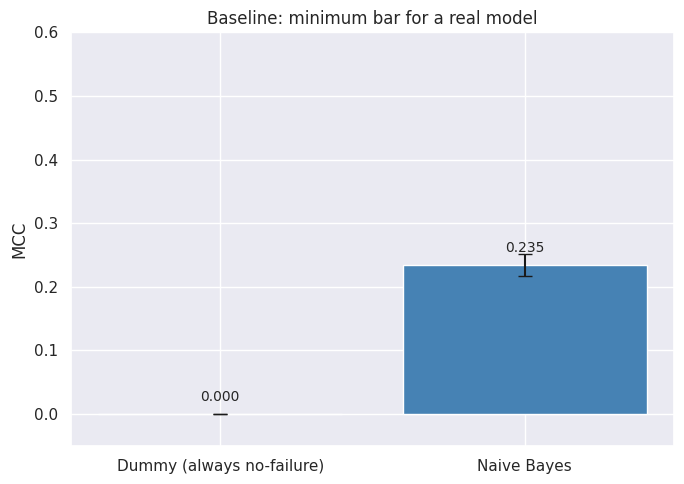

Naive Bayes floor MCC: 0.235 ± 0.017


In [7]:
# Q: What's the minimum bar any real model must beat?
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.dummy import DummyClassifier

y_arr = df['Machine failure'].to_numpy()
mcc_scorer = make_scorer(matthews_corrcoef)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy     = DummyClassifier(strategy='most_frequent')
dummy_mcc = cross_val_score(dummy, X_scaled, y_arr, cv=skf, scoring=mcc_scorer).mean()

gnb       = GaussianNB()
gnb_mcc   = cross_val_score(gnb, X_scaled, y_arr, cv=skf, scoring=mcc_scorer)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
ax.bar(x, [dummy_mcc, gnb_mcc.mean()], color=['lightcoral', 'steelblue'],
       yerr=[0, gnb_mcc.std()], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(['Dummy (always no-failure)', 'Naive Bayes'])
ax.set_ylabel('MCC')
ax.set_ylim(-0.05, 0.6)
ax.set_title('Baseline: minimum bar for a real model')
for i, v in enumerate([dummy_mcc, gnb_mcc.mean()]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/baseline.png', dpi=150)
plt.show()

print(f'Naive Bayes floor MCC: {gnb_mcc.mean():.3f} ± {gnb_mcc.std():.3f}')
